In [1]:
import numpy as np
import sys
import os
from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io, ase_io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System
import ase.io
import ml_dft.dft_utils as du
%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


In [2]:
data_dir = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/datasets/'

In [3]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

In [4]:
data = np.load(data_dir + 'h2o_dynamic_centered.npy', allow_pickle=True).item()
npy_pos = data['positions'][:10]
print('pos shape', npy_pos.shape)
ase_pos = du.npy_to_ase(npy_pos, data['atom_types'])
ions_list = []
for a in ase_pos:
    a.set_cell([4.1483, 4.1483, 4.1483])
    a.set_positions(a.positions + (4.1483 / 2))
    ions_list.append(ase_io.ase2ions(a))
    
for ions in ions_list:
    print(ions)
    
    
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)

gap = 0.4
grid = MakeGrid(metric,gap)

pos shape (10, 3, 3)
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [2.47061852 3.39651439 2.67979421]
 [4.35281594 5.21629046 3.14811936]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [5.10267249 2.94568056 2.24997598]
 [4.92288399 4.96707521 5.00262654]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [4.2195014  5.84419161 3.8650644 ]
 [1.97577301 4.7907429  4.05095297]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.91957544 3.91957544 3.91957544]
 [3.40724994 4.26058786 2.19654778]
 [3.00509167 5.43900224 3.59987348]]
                 nat : 3
                   Z : [8 1 1]
            

In [5]:
print('ions zval', ions.Zval)
print('ions labels', ions.labels)

ions zval {}
ions labels ['O' 'H' 'H']


In [6]:
path_pp = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/'
file_names = {'H': 'H.pbe-kjpaw_psl.0.1.UPF', 'C': 'C.pbe-kjpaw_psl.0.1.UPF',
             'O': 'O.pbe-n-kjpaw_psl.0.1.UPF'}
PP_list = {key: path_pp+file_names[key] for key in file_names.keys()}
print(PP_list)
PSEUDO = LocalPseudo(grid = grid, ions=None, PP_list=PP_list,PME=True)

{'H': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/H.pbe-kjpaw_psl.0.1.UPF', 'C': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/C.pbe-kjpaw_psl.0.1.UPF', 'O': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/O.pbe-n-kjpaw_psl.0.1.UPF'}
setting key: H
setting key: C
setting key: O


In [7]:
init_rhos = []
for ions in ions_list:
    PSEUDO.restart(grid=grid, ions=ions)
    rho_ini = guess_rho(grid, ions)
    init_rhos.append(rho_ini)

#rho_ini = guess_rho(grid,ions)

direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>
direct field cls <class 'dftpy.field.DirectField'>


In [8]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

In [11]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat


In [44]:
opt_rhos = []
for i in range(len(init_rhos)):
    rho = init_rhos[i]
    ions = ions_list[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')

    new_rho = opt.optimize_rho(guess_rho=rho)
    opt_rhos.append(new_rho)

evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy 1.6779869639474494e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476409
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.598478E+00    1       1       2.443790E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.606996501616968
evalfunctional XC
evalfunctional LDA
energy -1.8547306476899836
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.04815084333521661
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.8259973306255801
evalfunctional KEDF
evalfunctional x_TF_y

evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunction

evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.151424737114608
evalfunctional XC
evalfunctional LDA
energy -3.3333673260728447
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.512221604067877
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.614562144069964
9       -1.128428312896E+01     -1.719808E-04   2.413090E-04    5       1       1.255562E+00    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_v

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

...

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.723895046432919
evalfunctional XC
evalfunctional LDA
energy -3.2619847943941593
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.142489359458306
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.327906267399424
4       -1.072350665590E+01     -4.605169E-03   5.554386E-03    6       1       4

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.762485219720267
evalfunctional XC
evalfunctional LDA
energy -3.2647803616989286
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.150400951729508
evalfunctional PS

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.6072894633756187
evalfunctional XC
evalfunctional LDA
energy -1.854700893460632
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.0481865285890819
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.80095388944798
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 5.084047536780357
evalfunctional XC
evalfunctional LDA
energy -2.439411353712928
evalfunctional HARTREE
evalfunctional HARTREE
energy 2.249928798468621
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -13.997007498143633
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 18.8305379318758
evalfunctional XC
evalfunctional LDA
energy -4.422556328654741
evalfunctional HARTREE
evalfunctional HARTREE
energy 11.881355824740092
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -34.47202733093389
evalfunctional K

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.853085552957566
evalfunctional XC
evalfunctional LDA
energy -3.2857288161009834
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.262036509674399
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.762862036308032
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.893231078299095
evalfunctio

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.896605238003882
evalfunctional XC
evalfunctional LDA
energy -3.2921450922899473
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.293676012886784
evalfunctional PS

In [46]:
mols = []
for i in range(len(opt_rhos)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    Enew = E_v_Evaluator.Energy(rho=opt_rho, ions=ions, usePME = True)
    mol = System(ions,cell=grid,name='test',field=opt_rho)
    mols.append(mol)

    print('Energy New (a.u.)', Enew)
    print('Energy New (eV)', Enew * ENERGY_CONV['Hartree']['eV'])
    print('Energy New (eV/atom)', Enew * ENERGY_CONV['Hartree']['eV']/ions.nat)
    print('-' * 31, 'Time information', '-' * 31)
    print("{:28s}{:24s}{:20s}".format('Label', 'Cost(s)', 'Number'))
    for key in TimeData.cost :
        print("{:28s}{:<24.4f}{:<20d}".format(key, TimeData.cost[key], TimeData.number[key]))
    print('-' * 80)

gmax 8.01513505528424
Ewald : -4.158761314219369
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.151742456325007
evalfunctional XC
evalfunctional LDA
energy -3.334860936195654
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.521107720478991
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.622331861615947
Energy New (a.u.) -15.443103935226972
Energy New (eV) -420.22822249854397
Energy New (eV/atom) -140.07607416618131
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
TF                          4.4025                  8410                
vW                          14.7340                 8410                
FFT                         5.4351                  16883               
InvFFT                      6.1557                  16834               
LDA                         12.1808                 8410                
Hartree_Func                12.9528      

Ewald : -4.840396086158286
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.829692879965181
evalfunctional XC
evalfunctional LDA
energy -3.278675762052051
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.228383308524057
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -23.59994449327909
Energy New (a.u.) -15.660940153000189
Energy New (eV) -426.1558473448569
Energy New (eV/atom) -142.0519491149523
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
TF                          4.4083                  8422                
vW                          14.7554                 8422                
FFT                         5.4499                  16931               
InvFFT                      6.1665                  16864               
LDA                         12.1946                 8422                
Hartree_Func                12.9711                 8422           

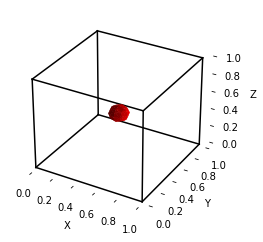

In [47]:
from dftpy.visualize.jupyter import view_density
view_density(mols[0])

In [72]:

for i in range(5,6):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    rho_ini = init_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    #print(opt_rho.grid.r)
    print('energy new', en_calc.Energy(rho=opt_rho, ions=ions, usePME=False))
    print('energy init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))

Ewald : -4.017185699312023
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.21238797035402
evalfunctional XC
evalfunctional LDA
energy -3.3456871477949175
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.578303699999834
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.822237715816854
energy new -15.39441889256994
Ewald : -4.017185699312023
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.0582458236747644
energy init -4.300964118236789


In [73]:
from equiv_dens.training.grids import CubicalGrid
grid_cl = CubicalGrid(None, nx=20, ny=20, nz=20, origin=[0, 0, 0], extent=np.diag(grid.lattice))
#print(grid_cl.coords)

In [74]:
from equiv_dens.nn.density_functionals.LDA import LDAFunctional
import torch
z_vals = []
for t in data['atom_types']:
    z_vals.append(ions.Zval[t])
z_vals = np.array(z_vals)
print(data['atom_numbers'])
print(z_vals)
lda = LDAFunctional(z_vals)
#print('rho ini', rho_ini)
for i in range(5,6):
    ions = ions_list[i]
    opt_rho = torch.tensor(opt_rhos[i])
    rho_ini = torch.tensor(init_rhos[i])
    #print('rho tensor', rho)
    pos = torch.tensor(ions.pos)
    PSEUDO.restart(grid=grid, ions=ions)
    print(lda(rho_ini, grid_cl, pos, PSEUDO))
    print(lda(opt_rho, grid_cl, pos, PSEUDO))

[8 1 1]
[6. 1. 1.]
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.0172, dtype=torch.float64)
thomas fermi energy tensor(1.4951, dtype=torch.float64)
pot type torch.DoubleTensor
rho type torch.DoubleTensor
von weizsacker energy tensor(-1.3513e-29, dtype=torch.float64)
tf_vw en tensor(1.4951, dtype=torch.float64)
lda energy tensor(-1.8372, dtype=torch.float64)
hartree energy tensor(2.5529e-33, dtype=torch.float64)
pseudo energy tensor(0.0582, dtype=torch.float64)
tensor(-4.3010, dtype=torch.float64)
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.0172, dtype=torch.float64)
thomas fermi energy tensor(7.1193, dtype=torch.float64)
pot type torch.DoubleTensor
rho type torch.Double

In [75]:
import torch.autograd as grad
import time
start = time.time()
opt_rho = torch.tensor(opt_rhos[0])
ions = ions_list[0]
pos = torch.tensor(ions.pos)
PSEUDO.restart(grid=grid, ions=ions)
opt_rho.requires_grad = True
en = lda(opt_rho, grid_cl, pos, PSEUDO)
#print('rho grad', opt_rho.grad)
#en.backward()
#print('rho grad', opt_rho.grad)
print(en)
print(time.time() - start)


rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.1588, dtype=torch.float64)
thomas fermi energy tensor(7.0747, dtype=torch.float64, grad_fn=<AsStridedBackward>)
pot type torch.DoubleTensor
rho type torch.DoubleTensor
von weizsacker energy tensor(3.0771, dtype=torch.float64, grad_fn=<MulBackward0>)
tf_vw en tensor(10.1517, dtype=torch.float64, grad_fn=<AddBackward0>)
lda energy tensor(-3.3349, dtype=torch.float64, grad_fn=<MulBackward0>)
hartree energy tensor(6.5211, dtype=torch.float64, grad_fn=<DivBackward0>)
pseudo energy tensor(-24.6223, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(-15.4431, dtype=torch.float64, grad_fn=<AddBackward0>)
0.026773691177368164


In [76]:
print('integral = ', torch.sum(opt_rho) * grid.dV)

integral =  tensor(8.0000, dtype=torch.float64, grad_fn=<MulBackward0>)


In [77]:
import torch.fft as tfft
opt_rho = torch.tensor(opt_rhos[0])
opt_rho.requires_grad = True
fft_rho = tfft.rfftn(opt_rho)
ss = torch.sum(fft_rho)
ss.backward()
print(opt_rho.grad)
    

tensor([[[ 4.4000e+03,  1.4211e-14,  4.0000e+02,  ..., -1.1497e-14,
           4.0000e+02, -1.3515e-14],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0

In [87]:
from equiv_dens.training.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.training.grids import cubical_grid, cubical_sampling

directory = '2020-10-15_8gYN9fzi'  # load directory name
model_name = '8gYN9fzi'

#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False
args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')

In [88]:
use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

#args.num_workers = 0
#args.dens_dataset = 'datasets/h2o_dynamic_pyscf_dft_f_en.npy'

cube_grid_fn = partial(cubical_grid, nx=20, ny=20, nz=20,
                       extent=np.array([4.1483, 4.1483, 4.1483]),
                       origin=np.array([-2.0318, -2.0318 , -2.0318]))
cube_sampling_fn = cubical_sampling

valid_cube_dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                                      orbitals_path=args.orbitals_file,
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file=args.radial_coeffs_file,
                                      dtype=args.dtype,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

loading density fromdatasets/h2o_dynamic_pyscf_dft.npy...
loading atoms fromdatasets/h2o_dynamic_centered.npy...
Starting atomsdata density init
Some variables
finished init


density shape (8000,)
idx [   8  408  808 1208 1608 2008 2408 2808 3208 3608 4008 4408 4808 5208
 5608 6008 6408 6808 7208 7608   28  428  828 1228 1628 2028 2428 2828
 3228 3628 4028 4428 4828 5228 5628 6028 6428 6828 7228 7628   48  448
  848 1248 1648 2048 2448 2848 3248 3648 4048 4448 4848 5248 5648 6048
 6448 6848 7248 7648   68  468  868 1268 1668 2068 2468 2868 3268 3668
 4068 4468 4868 5268 5668 6068 6468 6868 7268 7668   88  488  888 1288
 1688 2088 2488 2888 3288 3688 4088 4488 4888 5288 5688 6088 6488 6888
 7288 7688  108  508  908 1308 1708 2108 2508 2908 3308 3708 4108 4508
 4908 5308 5708 6108 6508 6908 7308 7708  128  528  928 1328 1728 2128
 2528 2928 3328 3728 4128 4528 4928 5328 5728 6128 6528 6928 7328 7728
  148  548  948 1348 1748 2148 2548 2948 3348 3748 4148 4548 4948 5348
 5748 6148 6548 6948 7348 7748  168  568  968 1368 1768 2168 2568 2968
 3368 3768 4168 4568 4968 5368 5768 6168 6568 6968 7368 7768  188  588
  988 1388 1788 2188 2588 2988 3388 3788 4188 4588 

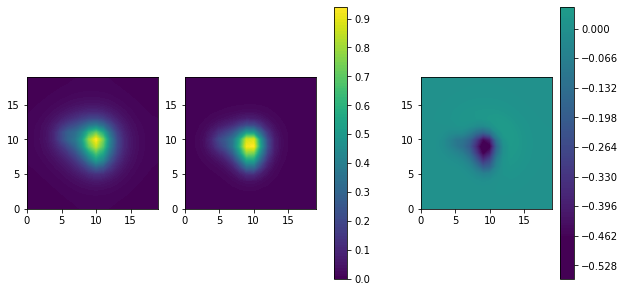

[[3.91957544 3.91957544 3.91957544]
 [2.16767095 4.15899805 2.9744327 ]
 [4.03705215 2.68404984 3.05287341]]


In [96]:
import matplotlib.pyplot as plt
sample = 5

dens_opt = opt_rhos[sample]
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens_opt = np.array(dens_opt)
dens_opt = dens_opt.reshape((8000, ))
print('density shape', dens_opt.shape)
x, y  = np.meshgrid(np.arange(20), np.arange(20))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 8
idx = np.ravel_multi_index((x_f, y_f, z_f), (20, 20, 20))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens_opt[idx]
dens2d = dens2d.reshape(20, 20)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

dens_data = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('density shape', dens_data.shape)

ax2 = fig.add_subplot(132)
print('idx', idx)
densd2d = dens_data[idx]
densd2d = densd2d.reshape(20, 20)

vmin = np.min(densd2d)
vmax = np.max(densd2d)
c2 = ax2.contourf(x, y, densd2d, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, dens2d-densd2d, vmin=-vmax/2, vmax=vmax/2, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()
print(ions_list[sample].pos)

In [79]:
print(npy_pos[sample])

[[ 0.          0.          0.        ]
 [-0.92706794  0.12669699 -0.500148  ]
 [ 0.062166   -0.653812   -0.45863897]]


pseudo shape (8000,)
idx [   8  408  808 1208 1608 2008 2408 2808 3208 3608 4008 4408 4808 5208
 5608 6008 6408 6808 7208 7608   28  428  828 1228 1628 2028 2428 2828
 3228 3628 4028 4428 4828 5228 5628 6028 6428 6828 7228 7628   48  448
  848 1248 1648 2048 2448 2848 3248 3648 4048 4448 4848 5248 5648 6048
 6448 6848 7248 7648   68  468  868 1268 1668 2068 2468 2868 3268 3668
 4068 4468 4868 5268 5668 6068 6468 6868 7268 7668   88  488  888 1288
 1688 2088 2488 2888 3288 3688 4088 4488 4888 5288 5688 6088 6488 6888
 7288 7688  108  508  908 1308 1708 2108 2508 2908 3308 3708 4108 4508
 4908 5308 5708 6108 6508 6908 7308 7708  128  528  928 1328 1728 2128
 2528 2928 3328 3728 4128 4528 4928 5328 5728 6128 6528 6928 7328 7728
  148  548  948 1348 1748 2148 2548 2948 3348 3748 4148 4548 4948 5348
 5748 6148 6548 6948 7348 7748  168  568  968 1368 1768 2168 2568 2968
 3368 3768 4168 4568 4968 5368 5768 6168 6568 6968 7368 7768  188  588
  988 1388 1788 2188 2588 2988 3388 3788 4188 4588 4

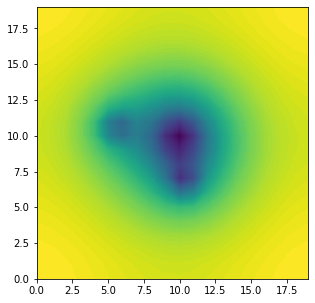

In [81]:
from equiv_dens.training.grids import CubicalGrid

PSEUDO.restart(grid=grid, ions=ions_list[sample])
dens = opt_rhos[5]
PSEUDO(dens)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
pot = np.array(PSEUDO.vreal)
pot = pot.reshape((8000, ))
print('pseudo shape', pot.shape)
x, y  = np.meshgrid(np.arange(20), np.arange(20))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 8
idx = np.ravel_multi_index((x_f, y_f, z_f), (20, 20, 20))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
pot2d = pot[idx]
pot2d = pot2d.reshape(20, 20)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(pot2d)
vmax = np.max(pot2d)
c1 = ax1.contourf(x, y, pot2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')